# Caso 3 - Análisis comparativo semántico entre declaraciones del 23F

Notebook final reproducible para detectar posibles contradicciones entre declaraciones del juicio 2/81 a partir de transcripciones del 23F.

In [10]:
# ============================================================
# 1. Imports y configuración general
# ============================================================
from pathlib import Path
import re
import json
import math
import warnings
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 180)

# Parámetros principales
DATA_PATHS = [
    Path('23f_scrappedDF.csv'),
    Path('data/23f_scrappedDF.csv'),
    Path('../data/23f_scrappedDF.csv')
]

OUTPUT_DIR = Path('outputs_caso3')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
MIN_DECLARATION_CHARS = 80
MAX_DECLARATION_CHARS = 1200

# Comparación semántica
SIM_MIN = 0.84          # Umbral alto para reducir pares y quedarnos con textos realmente comparables
SIM_MAX = 0.97          # Por encima suelen ser duplicados o casi duplicados
MAX_PAIRS_NLI = 1000    # Límite práctico para MacBook Air: evita ejecutar NLI sobre cientos de miles de pares
MAX_CHARS_NLI = 400     # Recorte por texto para evitar superar 512 tokens del modelo NLI

# Modelo recomendado para español/multilingüe
EMBEDDING_MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
NLI_MODEL_NAME = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'


In [11]:
# ============================================================
# 2. Carga del dataset con rutas relativas
# ============================================================
def find_existing_path(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError(
        'No se encontró 23f_scrappedDF.csv. Colócalo junto al notebook o en data/23f_scrappedDF.csv'
    )

DATA_PATH = find_existing_path(DATA_PATHS)
print(f'Dataset encontrado en: {DATA_PATH.resolve()}')

df = pd.read_csv(DATA_PATH)
print('Dimensiones:', df.shape)
display(df.head(3))


Dataset encontrado en: C:\Users\sophi\Documents\Curso 08 - Machine learning\Trabajo en grupo\23f_scrappedDF.csv
Dimensiones: (167, 7)


,title,url,pages,summary,tags,transcript,filename
0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,3,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y cert...",C/SG/2820/20-02-82||DTOR.||Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n- Solo ha tenido lugar la sesión de la ma...,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt
1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,4,"Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Supremo de Justicia Militar, dond...",C/SG/2896/22-02-82||Vista oral 2/81||Consejo Supremo de Justicia Militar,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.\n\n- A...,Vista oral 281 del Consejo Supremo de Justicia Militar 22 de febrero de 1982.txt
2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,5,"Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, marca...",C/SG/2992/24-02-82||Vista Oral 2/81||Consejo Supremo de Justicia Militar,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82\n\nA...,Vista oral 281 del Consejo Supremo de Justicia Militar 24 de febrero de 1982.txt


Columnas: ['title', 'url', 'pages', 'summary', 'tags', 'transcript', 'filename']
Nulos por columna:


,nulos
title,0
url,0
pages,0
summary,0
tags,0
transcript,0
filename,0


,title,filename,n_chars,n_words
count,167,167,167.000000,167.000000
unique,159,159,NaN,NaN
top,RESERVADO: comunicación procesamiento implicado.,RESERVADO comunicación procesamiento implicado.txt,NaN,NaN
freq,6,6,NaN,NaN
mean,NaN,NaN,11675.892216,2075.443114
std,NaN,NaN,37822.711182,7731.242472
min,NaN,NaN,455.000000,72.000000
25%,NaN,NaN,1495.500000,238.500000
50%,NaN,NaN,3529.000000,579.000000
75%,NaN,NaN,10524.000000,1771.500000


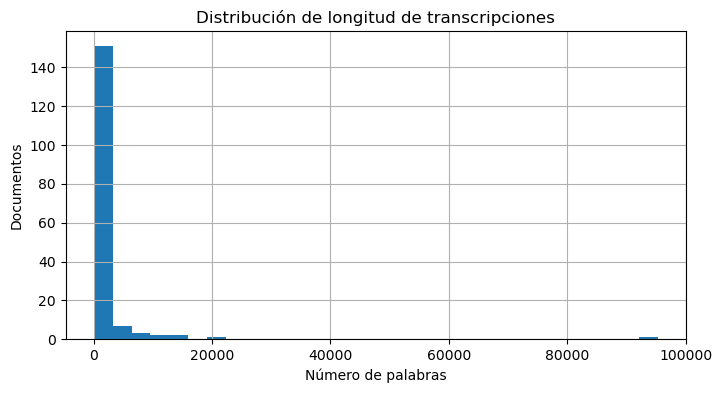

In [12]:
# ============================================================
# 3. EDA mínimo exigible para el informe
# ============================================================
print('Columnas:', df.columns.tolist())
print('Nulos por columna:')
display(df.isna().sum().to_frame('nulos'))

if 'transcript' not in df.columns:
    raise ValueError('El CSV debe contener una columna transcript')

df['transcript'] = df['transcript'].fillna('').astype(str)
df['title'] = df.get('title', pd.Series([''] * len(df))).fillna('').astype(str)
df['summary'] = df.get('summary', pd.Series([''] * len(df))).fillna('').astype(str)
df['tags'] = df.get('tags', pd.Series([''] * len(df))).fillna('').astype(str)
df['filename'] = df.get('filename', pd.Series([''] * len(df))).fillna('').astype(str)

df['n_chars'] = df['transcript'].str.len()
df['n_words'] = df['transcript'].str.split().str.len()

display(df[['title', 'filename', 'n_chars', 'n_words']].describe(include='all'))

plt.figure(figsize=(8, 4))
df['n_words'].hist(bins=30)
plt.title('Distribución de longitud de transcripciones')
plt.xlabel('Número de palabras')
plt.ylabel('Documentos')
plt.show()


In [13]:
# ============================================================
# 4. Preprocesamiento: limpieza, fechas y segmentación
# ============================================================
MESES = {
    'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
    'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9, 'octubre': 10,
    'noviembre': 11, 'diciembre': 12
}

def limpiar_texto(texto: str) -> str:
    texto = str(texto)
    texto = texto.replace(' ', ' ')
    texto = re.sub(r'\s+', ' ', texto)
    return texto.strip()

def normalizar_para_modelo(texto: str) -> str:
    texto = limpiar_texto(texto).lower()
    texto = re.sub(r'[^\w\s\.,;:¿?¡!\-áéíóúüñÁÉÍÓÚÜÑ]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

def extraer_fechas(texto: str):
    patron = r'(\d{1,2})\s+de\s+([a-záéíóúüñ]+)\s+de\s+(\d{4})|(\d{1,2})[/-](\d{1,2})[/-](\d{2,4})'
    fechas = []
    for m in re.finditer(patron, texto.lower(), flags=re.I):
        g = m.groups()
        try:
            if g[0] and g[1] and g[2]:
                dia, mes, anio = int(g[0]), MESES.get(g[1].lower()), int(g[2])
                if mes:
                    fechas.append(pd.Timestamp(year=anio, month=mes, day=dia))
            elif g[3] and g[4] and g[5]:
                dia, mes, anio = int(g[3]), int(g[4]), int(g[5])
                if anio < 100:
                    anio += 1900
                fechas.append(pd.Timestamp(year=anio, month=mes, day=dia))
        except Exception:
            pass
    return fechas

def segmentar_frases(texto: str):
    texto = limpiar_texto(texto)
    # Segmentación simple, suficiente para una primera extracción reproducible.
    partes = re.split(r'(?<=[\.\?\!])\s+', texto)
    return [p.strip() for p in partes if len(p.strip()) > 20]

df['texto_limpio'] = df['transcript'].apply(limpiar_texto)
df['fechas_detectadas'] = df['transcript'].apply(extraer_fechas)
df['fecha_principal'] = df['fechas_detectadas'].apply(lambda xs: xs[0] if xs else pd.NaT)

print('Documentos con fechas detectadas:', df['fecha_principal'].notna().sum(), '/', len(df))


Documentos con fechas detectadas: 99 / 167


In [14]:
# ============================================================
# 5. Declarantes: alias, normalización y extracción de declaraciones
# ============================================================
# Amplía este diccionario si en el análisis exploratorio aparecen más actores relevantes.
ALIASES = {
    'tejero': ['tejero', 'tejero molina', 'teniente coronel tejero', 'tcol tejero', 'antonio tejero'],
    'milans del bosch': ['milans', 'milans del bosch', 'general milans', 'jaime milans'],
    'armada': ['armada', 'alfonso armada', 'general armada', 'armada comyn'],
    'torres rojas': ['torres rojas', 'general torres rojas'],
    'garcía carrés': ['garcía carrés', 'garcia carres', 'comandante garcía carrés'],
    'gómez iglesias': ['gómez iglesias', 'gomez iglesias', 'capitán gómez iglesias'],
    'aramburu': ['aramburu', 'general aramburu', 'teniente general aramburu'],
    'juste': ['juste', 'general juste', 'teniente general juste'],
    'calderón': ['calderón', 'calderon'],
    'pardo zancada': ['pardo zancada'],
    'cortina': ['cortina'],
    'ibáñez inglés': ['ibáñez inglés', 'ibanez ingles'],
}

DECLARATION_VERBS = [
    'declara', 'declaró', 'declarado', 'afirma', 'afirmó', 'dice', 'dijo', 'manifiesta',
    'manifestó', 'niega', 'negó', 'reconoce', 'reconoció', 'sostiene', 'asegura',
    'aseguró', 'explica', 'explicó', 'responde', 'respondió', 'contesta', 'contestó',
    'interrogatorio', 'preguntado', 'preguntada'
]

def build_alias_regex(aliases):
    escaped = [re.escape(a) for a in aliases]
    return r'\b(?:' + '|'.join(sorted(escaped, key=len, reverse=True)) + r')\b'

ALIAS_REGEX = {actor: re.compile(build_alias_regex(aliases), flags=re.I) for actor, aliases in ALIASES.items()}
VERB_REGEX = re.compile(r'\b(?:' + '|'.join(map(re.escape, DECLARATION_VERBS)) + r')\b', flags=re.I)

def detectar_tipo_sesion(texto):
    t = texto.lower()
    if re.search(r'interrogatorio\s+(del\s+)?fiscal|ministerio fiscal|fiscal', t):
        return 'Fiscal'
    if re.search(r'interrogatorio\s+(de\s+)?(su\s+)?defensor|defensa|defensor', t):
        return 'Defensa'
    if re.search(r'alegato|alegación|alegaciones', t):
        return 'Alegato'
    return 'Desconocida'

def extraer_declaraciones_documento(row, window=1):
    frases = segmentar_frases(row['texto_limpio'])
    resultados = []
    for i, frase in enumerate(frases):
        actores = [actor for actor, rgx in ALIAS_REGEX.items() if rgx.search(frase)]
        if not actores:
            continue
        # Priorizamos frases con verbos declarativos, pero aceptamos menciones con contexto para no perder recall.
        tiene_verbo = bool(VERB_REGEX.search(frase))
        ini, fin = max(0, i-window), min(len(frases), i+window+1)
        contexto = ' '.join(frases[ini:fin])
        contexto = contexto[:MAX_DECLARATION_CHARS]
        if len(contexto) < MIN_DECLARATION_CHARS:
            continue
        for actor in actores:
            resultados.append({
                'doc_id': row.name,
                'documento_titulo': row['title'],
                'filename': row['filename'],
                'url': row.get('url', ''),
                'fecha': row['fecha_principal'],
                'sesion': detectar_tipo_sesion(row['texto_limpio']),
                'declarante': actor,
                'texto': contexto,
                'texto_norm': normalizar_para_modelo(contexto),
                'tiene_verbo_declarativo': tiene_verbo,
                'frase_central': frase
            })
    return resultados

registros = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extrayendo declaraciones'):
    registros.extend(extraer_declaraciones_documento(row))

if registros:
    decl = pd.DataFrame(registros).drop_duplicates(subset=['doc_id', 'declarante', 'texto_norm']).reset_index(drop=True)
else:
    decl = pd.DataFrame(columns=[
        'doc_id', 'documento_titulo', 'filename', 'url', 'fecha', 'sesion',
        'declarante', 'texto', 'texto_norm', 'tiene_verbo_declarativo', 'frase_central'
    ])

decl['declaracion_id'] = ['D%05d' % i for i in range(len(decl))]

print('Declaraciones candidatas extraídas:', len(decl))
if len(decl) == 0:
    print('No se han extraído declaraciones. Revisa ALIASES, las columnas de texto y los patrones regex.')
else:
    display(decl['declarante'].value_counts().to_frame('n_declaraciones'))
    display(decl.head(5))

decl.to_csv(OUTPUT_DIR / 'declaraciones_extraidas.csv', index=False)


Extrayendo declaraciones:   0%|          | 0/167 [00:00<?, ?it/s]

Declaraciones candidatas extraídas: 1978


,n_declaraciones
declarante,
tejero,603
armada,528
milans del bosch,263
cortina,137
gómez iglesias,103
juste,90
aramburu,80
garcía carrés,78
torres rojas,66


,doc_id,documento_titulo,filename,url,fecha,sesion,declarante,texto,texto_norm,tiene_verbo_declarativo,frase_central,declaracion_id
0,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,1982-02-20,Fiscal,tejero,"Manuel Miler Hidalgo (Ayte. 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. Careo Teniente Coronel TEJERO - SR.","manuel miler hidalgo ayte. 1ª, 2ª, 3ª y 4ª del teniente coronel tejero. careo teniente coronel tejero - sr.",False,"1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO.",D00000
1,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,1982-02-20,Fiscal,tejero,"1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. Careo Teniente Coronel TEJERO - SR. - Descanso de 11,50 horas a 12,13 horas.","1ª, 2ª, 3ª y 4ª del teniente coronel tejero. careo teniente coronel tejero - sr. - descanso de 11,50 horas a 12,13 horas.",False,Careo Teniente Coronel TEJERO - SR.,D00001
2,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,1982-02-20,Fiscal,tejero,"- Descanso de 11,50 horas a 12,13 horas. Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr.","- descanso de 11,50 horas a 12,13 horas. careo teniente coronel tejero - capitán gomez iglesias . certificación del presidente del congreso sr.",False,Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS .,D00002
3,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,1982-02-20,Fiscal,gómez iglesias,"- Descanso de 11,50 horas a 12,13 horas. Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr.","- descanso de 11,50 horas a 12,13 horas. careo teniente coronel tejero - capitán gomez iglesias . certificación del presidente del congreso sr.",False,Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS .,D00003
4,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,1982-02-20,Fiscal,tejero,Certificación del Presidente del Congreso Sr. Certificación sobre la situación militar del TCOL.TEJERO. 1ª y 3ª del Coronel D.,certificación del presidente del congreso sr. certificación sobre la situación militar del tcol.tejero. 1ª y 3ª del coronel d.,False,Certificación sobre la situación militar del TCOL.TEJERO.,D00004


In [15]:
# ============================================================
# 6. Temas aproximados por TF-IDF + clustering
# ============================================================
if len(decl) == 0:
    raise ValueError('No se extrajeron declaraciones. Revisa ALIASES, segmentación o transcript.')

N_CLUSTERS = min(8, max(2, len(decl) // 20))

tfidf_topics = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words=None, min_df=2)
X_topic = tfidf_topics.fit_transform(decl['texto_norm'])

if len(decl) >= N_CLUSTERS:
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    decl['tema_cluster'] = kmeans.fit_predict(X_topic)
    terms = np.array(tfidf_topics.get_feature_names_out())
    top_terms = {}
    for c in range(N_CLUSTERS):
        centro = kmeans.cluster_centers_[c]
        top_terms[c] = ', '.join(terms[centro.argsort()[-8:]][::-1])
    decl['tema_keywords'] = decl['tema_cluster'].map(top_terms)
else:
    decl['tema_cluster'] = 0
    decl['tema_keywords'] = ''

display(decl[['declaracion_id', 'declarante', 'tema_cluster', 'tema_keywords', 'texto']].head(10))


,declaracion_id,declarante,tema_cluster,tema_keywords,texto
0,D00000,tejero,6,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","Manuel Miler Hidalgo (Ayte. 1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. Careo Teniente Coronel TEJERO - SR."
1,D00001,tejero,6,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","1ª, 2ª, 3ª y 4ª del Teniente Coronel TEJERO. Careo Teniente Coronel TEJERO - SR. - Descanso de 11,50 horas a 12,13 horas."
2,D00002,tejero,3,"de, el, la, iglesias, cortina, del, que, en","- Descanso de 11,50 horas a 12,13 horas. Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr."
3,D00003,gómez iglesias,3,"de, el, la, iglesias, cortina, del, que, en","- Descanso de 11,50 horas a 12,13 horas. Careo Teniente Coronel TEJERO - Capitán GOMEZ IGLESIAS . Certificación del Presidente del Congreso Sr."
4,D00004,tejero,1,"que, el, de, la, en, no, tcol, del",Certificación del Presidente del Congreso Sr. Certificación sobre la situación militar del TCOL.TEJERO. 1ª y 3ª del Coronel D.
5,D00005,armada,1,"que, el, de, la, en, no, tcol, del",- Al finalizar la lectura de la segunda declaración del Coronel Ibañez el defensor del Gral. Armada hizo notar que se había omitido parte de la declaración; el presidente acced...
6,D00006,tejero,6,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero",Gobernador Civil de Valencia . Teniente Coronel Tejero - Continúa invocándose el protagonismo del REY y paralelamente el de la REINA; se afirma tenían conocimiento de lo que se...
7,D00007,tejero,6,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","- El CESID permanece en primera fila de declaraciones, con una nueva figura: el SECTOR DE VALENCIA. En la cuarta declaración del Teniente Coronel TEJERO afirma que había más pe..."
8,D00008,cortina,3,"de, el, la, iglesias, cortina, del, que, en",- Declaración del Comandante de Infantería D. José CORTINA --- PRIETO. - Diligencia de careo entre el Comandante CORTINA y el Teniente Coronel TEJERO.
9,D00009,tejero,6,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero",José CORTINA --- PRIETO. - Diligencia de careo entre el Comandante CORTINA y el Teniente Coronel TEJERO. - Primera declaración del Capitán de la Guardia Civil D.


In [16]:
# ============================================================
# 7. Embeddings multilingües, con fallback a TF-IDF
# ============================================================
def generar_embeddings(textos):
    try:
        from sentence_transformers import SentenceTransformer
        print('Cargando modelo de embeddings:', EMBEDDING_MODEL_NAME)
        model = SentenceTransformer(EMBEDDING_MODEL_NAME)
        emb = model.encode(textos, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
        return emb, 'sentence-transformers'
    except Exception as e:
        print('No se pudo usar SentenceTransformers. Fallback a TF-IDF. Motivo:', repr(e))
        vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
        emb = vec.fit_transform(textos).toarray()
        # Normalización L2 para similitud coseno
        norms = np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12
        emb = emb / norms
        return emb, 'tfidf-fallback'

embeddings, embedding_backend = generar_embeddings(decl['texto_norm'].tolist())
print('Backend:', embedding_backend, '| Shape:', embeddings.shape)


Cargando modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Backend: sentence-transformers | Shape: (1978, 384)


In [17]:
# ============================================================
# 8. Generación de pares candidatos intra/inter-declarante
# ============================================================
sim_matrix = cosine_similarity(embeddings)

pairs = []
for i, j in combinations(range(len(decl)), 2):
    sim = float(sim_matrix[i, j])
    if not (SIM_MIN <= sim <= SIM_MAX):
        continue
    same_actor = decl.loc[i, 'declarante'] == decl.loc[j, 'declarante']
    same_topic = decl.loc[i, 'tema_cluster'] == decl.loc[j, 'tema_cluster']
    # Filtro razonable: mismo actor o mismo tema aproximado.
    if not (same_actor or same_topic):
        continue
    pairs.append({
        'id_1': decl.loc[i, 'declaracion_id'],
        'id_2': decl.loc[j, 'declaracion_id'],
        'actor_1': decl.loc[i, 'declarante'],
        'actor_2': decl.loc[j, 'declarante'],
        'tipo_comparacion': 'intra-declarante' if same_actor else 'inter-declarante',
        'tema_1': int(decl.loc[i, 'tema_cluster']),
        'tema_2': int(decl.loc[j, 'tema_cluster']),
        'tema_keywords_1': decl.loc[i, 'tema_keywords'],
        'tema_keywords_2': decl.loc[j, 'tema_keywords'],
        'similitud_coseno': sim,
        'texto_1': decl.loc[i, 'texto'],
        'texto_2': decl.loc[j, 'texto'],
        'documento_1': decl.loc[i, 'documento_titulo'],
        'documento_2': decl.loc[j, 'documento_titulo'],
        'fecha_1': decl.loc[i, 'fecha'],
        'fecha_2': decl.loc[j, 'fecha'],
        'sesion_1': decl.loc[i, 'sesion'],
        'sesion_2': decl.loc[j, 'sesion'],
        'url_1': decl.loc[i, 'url'],
        'url_2': decl.loc[j, 'url'],
    })

pares = pd.DataFrame(pairs).sort_values('similitud_coseno', ascending=False).reset_index(drop=True)
print('Pares candidatos antes de limitar:', len(pares))

# Limitamos antes de NLI: el modelo NLI es el cuello de botella.
# Con 1000 pares suele tardar minutos; con 500.000 pares puede tardar muchas horas en CPU.
if MAX_PAIRS_NLI is not None and len(pares) > MAX_PAIRS_NLI:
    pares = pares.head(MAX_PAIRS_NLI).copy()

print('Pares candidatos que se enviarán a NLI:', len(pares))
display(pares[['actor_1','actor_2','tipo_comparacion','similitud_coseno','tema_keywords_1','texto_1','texto_2']].head(10))
pares.to_csv(OUTPUT_DIR / 'pares_candidatos.csv', index=False)


Pares candidatos antes de limitar: 658
Pares candidatos que se enviarán a NLI: 658


,actor_1,actor_2,tipo_comparacion,similitud_coseno,tema_keywords_1,texto_1,texto_2
0,tejero,tejero,intra-declarante,0.969063,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","RELATO DE UN PERIODISTA, TESTIGO PRESENCIAL. MADRID, 23 (EFE).- MINUTOS ANTES DE LAS 18,30 HORAS, CUANDO SE REALIZADA LA VOTACION DE INVESTIGURA DE LEOPOLDO CALVO SOTELO, COMO ...","MADRID, 23 (EFE).- MINUTOS ANTES DE LAS 18,30 HORAS, CUANDO SE REALIZADA LA VOTACION DE INVESTIGURA DE LEOPOLDO CALVO SOTELO, COMO PRESIDENTE DEL GOBIERNO, EFECTIVOS DE LA GUAR..."
1,tejero,tejero,intra-declarante,0.968991,"de, que, llamada, llamada de, me, no, la, sí","A - De acuerdo, Adiós. --- **LLAMADA DESDE LA CASA DE LA SRA TEJERO A UN TAL MARTIN.** B - Dígame A - Martin? Si acaso te llama dile que estoy en casa de Tejero, que estoy espe...","--- **LLAMADA DESDE LA CASA DE LA SRA TEJERO A UN TAL MARTIN.** B - Dígame A - Martin? Si acaso te llama dile que estoy en casa de Tejero, que estoy esperando a ver si viene po..."
2,tejero,tejero,intra-declarante,0.968197,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","Don José de su repase a ser pretendía, real y po. ""Diario de Examinar rísticas y chos escribo coincidencia a «Diario de Mundo de la Jefatura de A., p Dirección General de la Gu...","""Diario de Examinar rísticas y chos escribo coincidencia a «Diario de Mundo de la Jefatura de A., p Dirección General de la Guardia Civil ESTADO MAYOR 2.ª SECCION INFORMACION D..."
3,gómez iglesias,cortina,inter-declarante,0.967920,"de, el, la, iglesias, cortina, del, que, en","### Conocimiento previo de los hechos. El Capitán Garcia Almenta, el Capitán Gómez Iglesias, el Sargento Miguel Sales así como el Cabo Monge Segura, conocían los hechos concret...","El Capitán Garcia Almenta, el Capitán Gómez Iglesias, el Sargento Miguel Sales así como el Cabo Monge Segura, conocían los hechos concretos del 23 de Febrero antes de que ocurr..."
4,cortina,cortina,intra-declarante,0.967203,"de, el, la, iglesias, cortina, del, que, en","Por sí solas se desvirtúan. El abogado alude después a que si el Comandante Cortina hubiera intervenido, se habría organizado todo mucho mejor. Repasa, seguidamente, las conver...","El abogado alude después a que si el Comandante Cortina hubiera intervenido, se habría organizado todo mucho mejor. Repasa, seguidamente, las conversaciones telefónicas (supues..."
5,tejero,tejero,intra-declarante,0.967182,"de, la, el, teniente coronel, teniente, coronel, del, coronel tejero","Al frente del grupo figuraba Agustín Utrera Martín, delegado provincial de Fuerza Nueva, si bien todos los componentes del grupo no pertenecen a este partido. El teniente coron...","Al frente del grupo figuraba Agustín Utrera Martín, delegado provincial de Fuerza Nueva, si bien, todos los componentes del grupo no pertenecen a este partido. Como se recordar..."
6,juste,torres rojas,inter-declarante,0.965800,"general, torres, juste, general juste, rojas, torres rojas, el, general torres","- No habló con el General Armada en la BRIPAC, aunque lo vio. - Considera que el General Juste, aunque pasivo y sin dar órdenes directas, aceptó cuantas se dieron en su presenc...","- Considera que el General Juste, aunque pasivo y sin dar órdenes directas, aceptó cuantas se dieron en su presencia. El Coronel San Martín no intervino en estas órdenes y el G..."
7,milans del bosch,armada,inter-declarante,0.965770,"milans del, del bosch, bosch, del, milans, de, el, general","- Se logra comunicación con la 3ª Región Militar. EL REY habla con el Teniente General MILANS DEL BOSCH quien dice: ""Que está a las órdenes del Rey"" ""Que ha tomado medidas de s...","EL REY habla con el Teniente General MILANS DEL BOSCH quien dice: ""Que está a las órdenes del Rey"" ""Que ha tomado medidas de seguridad para preservar el orden"". ha hablado con ..."
8,armada,armada,intra-declarante,0.965209,"general, el, general armada, armada, que, el general, al, de",- La no existencia de una lista pre

In [18]:
# ============================================================
# 9. Detección de contradicciones con NLI multilingüe
# ============================================================
def cargar_nli():
    try:
        from transformers import pipeline
        print('Cargando modelo NLI:', NLI_MODEL_NAME)
        clf = pipeline('text-classification', model=NLI_MODEL_NAME, tokenizer=NLI_MODEL_NAME, return_all_scores=True, truncation=True)
        return clf, 'transformers-nli'
    except Exception as e:
        print('No se pudo cargar el modelo NLI. Se usará heurística. Motivo:', repr(e))
        return None, 'heuristica'

nli, nli_backend = cargar_nli()

def score_nli(texto_1, texto_2):
    # Recorta para evitar superar límites de tokens.
    t1 = str(texto_1)[:MAX_CHARS_NLI]
    t2 = str(texto_2)[:MAX_CHARS_NLI]
    if nli is not None:
        try:
            # Pipeline de pares premise/hypothesis.
            out = nli({'text': t1, 'text_pair': t2})[0]
            scores = {d['label'].lower(): float(d['score']) for d in out}
            contradiction = max([v for k, v in scores.items() if 'contrad' in k], default=0.0)
            entailment = max([v for k, v in scores.items() if 'entail' in k], default=0.0)
            neutral = max([v for k, v in scores.items() if 'neutral' in k], default=0.0)
            label = 'contradiccion' if contradiction >= max(entailment, neutral) else ('consistencia' if entailment >= neutral else 'neutral')
            return label, contradiction, entailment, neutral
        except Exception as e:
            # Si falla un par concreto, cae a heurística.
            pass

    # Fallback: heurística basada en negaciones y conectores adversativos. No sustituye a NLI.
    neg = [' no ', ' nunca ', ' jamás ', ' ninguno ', ' nadie ', ' ni ']
    adv = ['pero', 'sin embargo', 'aunque', 'contrariamente', 'en cambio']
    a = ' ' + t1.lower() + ' '
    b = ' ' + t2.lower() + ' '
    neg_diff = abs(sum(x in a for x in neg) - sum(x in b for x in neg))
    adv_score = 0.15 if any(x in a or x in b for x in adv) else 0.0
    contradiction = min(0.75, 0.25 + 0.20 * neg_diff + adv_score)
    entailment = 0.20
    neutral = 1.0 - contradiction - entailment
    label = 'contradiccion' if contradiction >= 0.50 else 'neutral'
    return label, contradiction, entailment, max(0.0, neutral)

pares_nli = pares.copy()
if MAX_PAIRS_NLI is not None:
    pares_nli = pares_nli.head(MAX_PAIRS_NLI).copy()
print('Pares enviados finalmente a NLI:', len(pares_nli), '| Recorte por texto:', MAX_CHARS_NLI, 'caracteres')

labels, s_contra, s_entail, s_neutral = [], [], [], []
for _, row in tqdm(pares_nli.iterrows(), total=len(pares_nli), desc='Aplicando NLI'):
    lab, c, e, n = score_nli(row['texto_1'], row['texto_2'])
    labels.append(lab); s_contra.append(c); s_entail.append(e); s_neutral.append(n)

pares_nli['nli_label'] = labels
pares_nli['score_contradiccion'] = s_contra
pares_nli['score_entailment'] = s_entail
pares_nli['score_neutral'] = s_neutral
pares_nli['nli_backend'] = nli_backend

# Ranking final: alta contradicción + similitud suficiente.
pares_nli['score_ranking'] = pares_nli['score_contradiccion'] * pares_nli['similitud_coseno']
resultados = pares_nli.sort_values(['score_contradiccion', 'score_ranking'], ascending=False).reset_index(drop=True)

print('Backend NLI:', nli_backend)
print('Pares evaluados con NLI/heurística:', len(resultados))
display(resultados[['actor_1','actor_2','tipo_comparacion','similitud_coseno','score_contradiccion','nli_label','texto_1','texto_2']].head(15))

resultados.to_csv(OUTPUT_DIR / 'ranking_contradicciones.csv', index=False)


Cargando modelo NLI: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Pares enviados finalmente a NLI: 658 | Recorte por texto: 400 caracteres


Aplicando NLI:   0%|          | 0/658 [00:00<?, ?it/s]

Backend NLI: transformers-nli
Pares evaluados con NLI/heurística: 658


,actor_1,actor_2,tipo_comparacion,similitud_coseno,score_contradiccion,nli_label,texto_1,texto_2
0,juste,armada,inter-declarante,0.842731,0.75,contradiccion,"- La autorización al General Armada a trasladarse al Congreso fue únicamente para gestionar la salida, pero de ninguna manera (y esto lo ha repetido innumerables veces) para pr...","- Sobre los motivos del cese del General Justé no le deja contestar el Presidente. - Insiste en que el General Armada, a la vuelta del Congreso no le informó que había intentad..."
1,armada,armada,intra-declarante,0.842731,0.75,contradiccion,"- La autorización al General Armada a trasladarse al Congreso fue únicamente para gestionar la salida, pero de ninguna manera (y esto lo ha repetido innumerables veces) para pr...","- Sobre los motivos del cese del General Justé no le deja contestar el Presidente. - Insiste en que el General Armada, a la vuelta del Congreso no le informó que había intentad..."
2,armada,armada,intra-declarante,0.905842,0.65,contradiccion,"Nadie sabe quien es ese militar, ni tan siquiera el propio Tejero. 12.- Al producirse el asalto al Congreso, el general Armada está despachando con el general Gabeiras, primer ...","12.- Al producirse el asalto al Congreso, el general Armada está despachando con el general Gabeiras, primer Jefe de Estado Mayor. Armada comete el primer error. Diplomaticamen..."
3,milans del bosch,milans del bosch,intra-declarante,0.889463,0.65,contradiccion,A esto y de manera muy amplia reitera que se debe a -- una confusión del General Pascual. - La llamada del Teniente General Milans del Boch al General Armada en la noche del 23...,- La llamada del Teniente General Milans del Boch al General Armada en la noche del 23-F sobre la propuesta de la llamada solución Armada. El interrogado General mantiene que l...
4,armada,milans del bosch,inter-declarante,0.889463,0.65,contradiccion,A esto y de manera muy amplia reitera que se debe a -- una confusión del General Pascual. - La llamada del Teniente General Milans del Boch al General Armada en la noche del 23...,- La llamada del Teniente General Milans del Boch al General Armada en la noche del 23-F sobre la propuesta de la llamada solución Armada. El interrogado General mantiene que l...
5,tejero,armada,inter-declarante,0.857690,0.65,contradiccion,"- 4 - 2.5.- Interrogatorio del Fiscal al Coronel Manchado.- Muy extensamente y ante la casi exasperación del Fiscal, sólo ha reconocido que el Tcol. Tejero le pidió 6 conductor...","Tejero le pidió 6 conductores, a las 10 de la mañana, y que se los dio sin vacilar; que, a las 16 horas volvió a pedir 6 autobuses y 50 hombres para ir al Congreso, a una misió..."
6,tejero,tejero,intra-declarante,0.857690,0.65,contradiccion,"- 4 - 2.5.- Interrogatorio del Fiscal al Coronel Manchado.- Muy extensamente y ante la casi exasperación del Fiscal, sólo ha reconocido que el Tcol. Tejero le pidió 6 conductor...","Tejero le pidió 6 conductores, a las 10 de la mañana, y que se los dio sin vacilar; que, a las 16 horas volvió a pedir 6 autobuses y 50 hombres para ir al Congreso, a una misió..."
7,tejero,aramburu,inter-declarante,0.857690,0.65,contradiccion,"- 4 - 2.5.- Interrogatorio del Fiscal al Coronel Manchado.- Muy extensamente y ante la casi exasperación del Fiscal, sólo ha reconocido que el Tcol. Tejero le pidió 6 conductor...","Tejero le pidió 6 conductores, a las 10 de la mañana, y que se los dio sin vacilar; que, a las 16 horas volvió a pedir 6 autobuses y 50 hombres para ir al Congreso, a una misió..."
8,juste,milans del bosch,inter-declarante,0.961151,0.60,contradiccion,"Pero no se dio órdenes para ello. - Se le dijo que ni los otros Capitanes Generales, ni los Generales Juste y Saez de Santa María sabían nada, aunque ""se sumarían"". - Ya en esa...","- Se le dijo que ni los otros Capitanes Generales, ni los Generales Juste y Saez de Santa María sabían nada, aunque ""se sumarían"". - Ya en esa primera reunión el General Milans..."
9,juste,armada,inter-declarante,0.961151,0

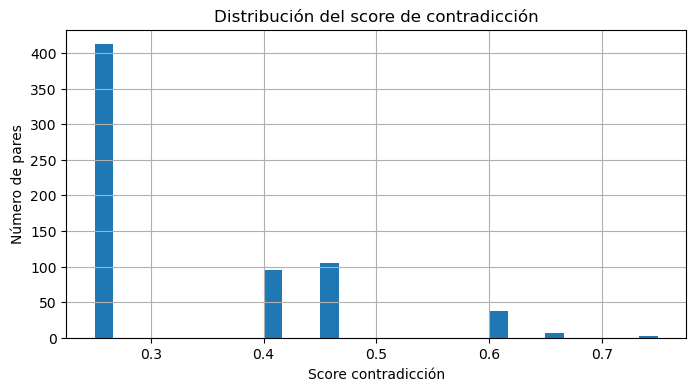

,par_actor,n_pares,score_medio,score_max
0,armada vs armada,104,0.359135,0.75
1,juste vs armada,3,0.650000,0.75
2,armada vs milans del bosch,22,0.315909,0.65
3,tejero vs aramburu,16,0.362500,0.65
4,tejero vs armada,45,0.347778,0.65
5,tejero vs tejero,162,0.303395,0.65
6,milans del bosch vs milans del bosch,21,0.311905,0.65
7,armada vs cortina,3,0.416667,0.60
8,armada vs juste,8,0.425000,0.60
9,armada vs aramburu,10,0.365000,0.60


In [19]:
# ============================================================
# 10. Visualización e interpretación de resultados
# ============================================================
if len(resultados) > 0:
    plt.figure(figsize=(8, 4))
    resultados['score_contradiccion'].hist(bins=30)
    plt.title('Distribución del score de contradicción')
    plt.xlabel('Score contradicción')
    plt.ylabel('Número de pares')
    plt.show()

    resumen_actor = (
        resultados
        .assign(par_actor=resultados['actor_1'] + ' vs ' + resultados['actor_2'])
        .groupby('par_actor')
        .agg(n_pares=('score_contradiccion','size'), score_medio=('score_contradiccion','mean'), score_max=('score_contradiccion','max'))
        .sort_values('score_max', ascending=False)
        .reset_index()
    )
    display(resumen_actor.head(20))

    top = resultados.head(10).copy()
    top[['actor_1','actor_2','tipo_comparacion','score_contradiccion','similitud_coseno','documento_1','documento_2','texto_1','texto_2']]
else:
    print('No hay resultados. Revisa umbrales SIM_MIN/SIM_MAX o extracción de declaraciones.')


In [20]:
# ============================================================
# 11. Validación manual: plantilla y métricas
# ============================================================
# Este paso es clave para el informe: no basta con mostrar rankings.
# Etiquetad manualmente una muestra como: 1 = contradicción real, 0 = no contradicción.

N_VALIDACION = min(50, len(resultados))
validacion = resultados.head(N_VALIDACION).copy()
validacion['validacion_manual'] = ''  # completar con 1/0
validacion['comentario_validador'] = ''

cols_validacion = [
    'actor_1','actor_2','tipo_comparacion','score_contradiccion','similitud_coseno',
    'documento_1','documento_2','texto_1','texto_2','validacion_manual','comentario_validador'
]
validacion[cols_validacion].to_csv(OUTPUT_DIR / 'plantilla_validacion_manual.csv', index=False)
print('Plantilla creada:', OUTPUT_DIR / 'plantilla_validacion_manual.csv')
display(validacion[cols_validacion].head(10))


Plantilla creada: outputs_caso3\plantilla_validacion_manual.csv


,actor_1,actor_2,tipo_comparacion,score_contradiccion,similitud_coseno,documento_1,documento_2,texto_1,texto_2,validacion_manual,comentario_validador
0,juste,armada,inter-declarante,0.75,0.842731,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de abril de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de abril de 1982).,"- La autorización al General Armada a trasladarse al Congreso fue únicamente para gestionar la salida, pero de ninguna manera (y esto lo ha repetido innumerables veces) para pr...","- Sobre los motivos del cese del General Justé no le deja contestar el Presidente. - Insiste en que el General Armada, a la vuelta del Congreso no le informó que había intentad...",,
1,armada,armada,intra-declarante,0.75,0.842731,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de abril de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de abril de 1982).,"- La autorización al General Armada a trasladarse al Congreso fue únicamente para gestionar la salida, pero de ninguna manera (y esto lo ha repetido innumerables veces) para pr...","- Sobre los motivos del cese del General Justé no le deja contestar el Presidente. - Insiste en que el General Armada, a la vuelta del Congreso no le informó que había intentad...",,
2,armada,armada,intra-declarante,0.65,0.905842,"""Nota """"Campaña contra S.M."""" (sin firma).""","""Nota """"Campaña contra S.M."""" (sin firma).""","Nadie sabe quien es ese militar, ni tan siquiera el propio Tejero. 12.- Al producirse el asalto al Congreso, el general Armada está despachando con el general Gabeiras, primer ...","12.- Al producirse el asalto al Congreso, el general Armada está despachando con el general Gabeiras, primer Jefe de Estado Mayor. Armada comete el primer error. Diplomaticamen...",,
3,milans del bosch,milans del bosch,intra-declarante,0.65,0.889463,Vista oral 2/81 del Consejo Supremo de Justicia Militar (9 de marzo de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (9 de marzo de 1982).,A esto y de manera muy amplia reitera que se debe a -- una confusión del General Pascual. - La llamada del Teniente General Milans del Boch al General Armada en la noche del 23...,- La llamada del Teniente General Milans del Boch al General Armada en la noche del 23-F sobre la propuesta de la llamada solución Armada. El interrogado General mantiene que l...,,
4,armada,milans del bosch,inter-declarante,0.65,0.889463,Vista oral 2/81 del Consejo Supremo de Justicia Militar (9 de marzo de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (9 de marzo de 1982).,A esto y de manera muy amplia reitera que se debe a -- una confusión del General Pascual. - La llamada del Teniente General Milans del Boch al General Armada en la noche del 23...,- La llamada del Teniente General Milans del Boch al General Armada en la noche del 23-F sobre la propuesta de la llamada solución Armada. El interrogado General mantiene que l...,,
5,tejero,armada,inter-declarante,0.65,0.857690,Vista oral 2/81 del Consejo Supremo de Justicia Militar (16 de marzo de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (16 de marzo de 1982).,"- 4 - 2.5.- Interrogatorio del Fiscal al Coronel Manchado.- Muy extensamente y ante la casi exasperación del Fiscal, sólo ha reconocido que el Tcol. Tejero le pidió 6 conductor...","Tejero le pidió 6 conductores, a las 10 de la mañana, y que se los dio sin vacilar; que, a las 16 horas volvió a pedir 6 autobuses y 50 hombres para ir al Congreso, a una misió...",,
6,tejero,tejero,intra-declarante,0.65,0.857690,Vista oral 2/81 del Consejo Supremo de Justicia Militar (16 de marzo de 1982).,Vista oral 2/81 del Consejo Supremo de Justicia Militar (16 de marzo de 1982).,"- 4 - 2.5.- Interrogatorio del Fiscal al Coronel Manchado.- Muy extensamente y ante la casi exasperación del Fiscal, sólo ha reconocido que el Tcol. Tejero le pidió 6 conductor...","Tejero le pidió 6 conductores, a las 10 de la mañana, y que se los dio sin va

In [21]:
# ============================================================
# 12. Cálculo de métricas tras validación manual
# ==========================================================

val = pd.read_excel(OUTPUT_DIR / 'plantilla_validacion_manual_ETIQUETADA.xlsx')

val['validacion_manual'] = pd.to_numeric(val['validacion_manual'], errors='coerce')
val_etiquetada = val.dropna(subset=['validacion_manual']).copy()

if len(val_etiquetada) == 0:
    print('Todavía no hay filas validadas manualmente. Completa la columna validacion_manual con 1/0.')
else:
    umbral = 0.50
    val_etiquetada['prediccion_binaria'] = (val_etiquetada['score_contradiccion'] >= umbral).astype(int)
    precision_top = val_etiquetada['validacion_manual'].mean()
    accuracy_umbral = (val_etiquetada['prediccion_binaria'] == val_etiquetada['validacion_manual']).mean()
    print(f'Filas validadas: {len(val_etiquetada)}')
    print(f'Precisión del ranking top-{len(val_etiquetada)}: {precision_top:.3f}')
    print(f'Accuracy con umbral {umbral}: {accuracy_umbral:.3f}')
    display(pd.crosstab(val_etiquetada['validacion_manual'], val_etiquetada['prediccion_binaria'], rownames=['Manual'], colnames=['Modelo']))


Filas validadas: 50
Precisión del ranking top-50: 0.100
Accuracy con umbral 0.5: 0.140


Modelo,0,1
Manual,,
0,2,43
1,0,5
